# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: BALANCED PURE DINOv2 (ViT + SwAV + iBOT + KoLeo) + FINE-TUNING on: cuda
Loading Data/network_connections.csv...

--- PHASE A: PREPROCESSING (PURE) ---

--- PHASE 1: SSL PRETRAINING (DINO + iBOT) ---
Epoch 1 | Loss: 6.3082
Epoch 2 | Loss: 5.4890
Epoch 3 | Loss: 5.0771
Epoch 4 | Loss: 4.9039
Epoch 5 | Loss: 4.6437
Epoch 6 | Loss: 4.5340
Epoch 7 | Loss: 4.4086
Epoch 8 | Loss: 4.2734
Epoch 9 | Loss: 4.2042
Epoch 10 | Loss: 4.1217
Epoch 11 | Loss: 4.0684
Epoch 12 | Loss: 3.9948
Epoch 13 | Loss: 3.9908
Epoch 14 | Loss: 3.9543
Epoch 15 | Loss: 3.9276

--- PHASE 2: BALANCED FINE-TUNING (CORE MODEL) ---
Starting Fine-Tuning for 20 epochs...
Fine-Tune Epoch 01 | Loss: 0.1813 | Train Acc: 96.36%
Fine-Tune Epoch 02 | Loss: 0.0131 | Train Acc: 99.69%
Fine-Tune Epoch 03 | Loss: 0.0078 | Train Acc: 99.81%
Fine-Tune Epoch 04 | Loss: 0.0062 | Train Acc: 99.84%
Fine-Tune Epoch 05 | Loss: 0.0066 | Train Acc: 99.83%
Fine-Tune Epoch 06 | Loss: 0.0051 | Train Acc: 99.87%
Fine-Tune Epoch 07 | Los

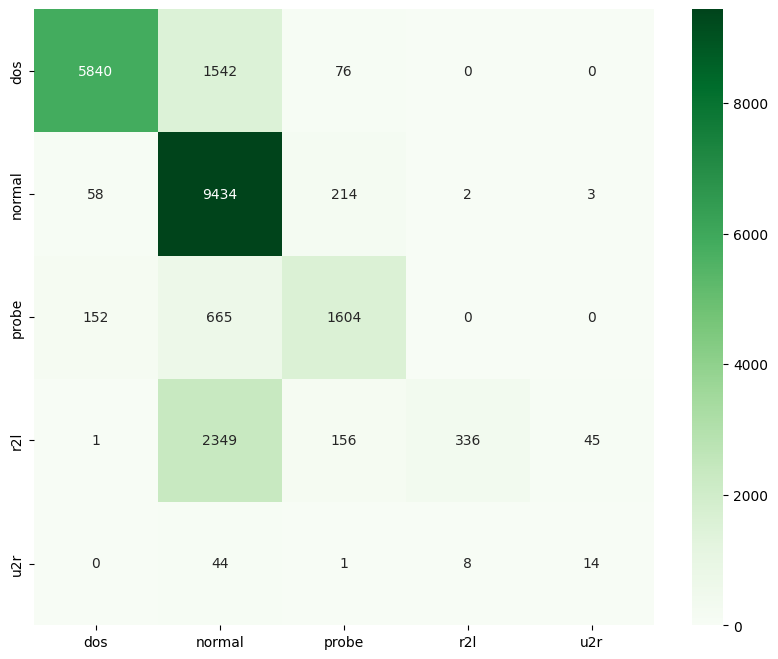

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 PIPELINE: MoCA-FUSION HYBRID NIDS on: {device}")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_and_prep(path):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

# NOTE: Ensure you have your data file at this path
# Falls die Datei nicht existiert, bitte Pfad anpassen!
try:
    X, y = load_and_prep('Data/network_connections.csv')
except FileNotFoundError:
    print("⚠️ WARNUNG: 'Data/network_connections.csv' nicht gefunden. Bitte Pfad prüfen.")
    # Dummy Data für Testzwecke falls Datei fehlt
    X = pd.DataFrame(np.random.rand(1000, 20), columns=[f'col_{i}' for i in range(20)])
    y = pd.Series(np.random.choice(['normal', 'dos', 'probe', 'r2l', 'u2r'], 1000))

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)
train_cols = X.columns.tolist()
del X, y
gc.collect()

# ==========================================
# 2. RICH FEATURE ENGINEERING (Phase A)
# ==========================================
print("\n--- PHASE A: ENGINEERING RICH FEATURES ---")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw).astype(np.float32)

# 2.1 NCA (Metric Learning Feature)
print("1. NCA (Metric Learning)...")
nca_components = 15
nca = NeighborhoodComponentsAnalysis(n_components=nca_components, random_state=42)
idx_sample = np.random.choice(len(X_train_sc), size=min(5000, len(X_train_sc)), replace=False)
nca.fit(X_train_sc[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)

# 2.2 Isolation Forests (Anomaly Scores)
print("2. Isolation Forests...")
iso_models = {}
iso_feats_train = []
unique_classes_train = np.unique(y_train)
for cls_idx in unique_classes_train:
    X_cls = X_train_sc[y_train == cls_idx]
    if len(X_cls) < 50: 
        # Fallback für sehr kleine Klassen
        iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
        iso.fit(X_train_sc) # Train on all if class too small
    else:
        iso = IsolationForest(n_estimators=50, contamination=0.01, n_jobs=-1, random_state=42)
        iso.fit(X_cls)
    
    iso_models[cls_idx] = iso
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))

X_train_iso = np.hstack(iso_feats_train)

# 2.3 Autoencoder (Reconstruction Error)
print("3. Autoencoder...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x): return self.net(x)

ae = Autoencoder(X_train_sc.shape[1]).to(device)
ae_opt = optim.Adam(ae.parameters(), lr=0.005)
ae_loader = DataLoader(TensorDataset(torch.tensor(X_train_sc)), batch_size=512, shuffle=True)

for epoch in range(5): # Kurzes Training reicht oft für AE
    for batch in ae_loader:
        x = batch[0].to(device)
        loss = F.mse_loss(ae(x), x)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()

def get_recon_error_batched(data):
    ae.eval()
    loader = DataLoader(TensorDataset(torch.tensor(data)), batch_size=2048, shuffle=False)
    errors = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            recon = ae(x)
            err = torch.mean((x - recon)**2, dim=1).cpu().numpy()
            errors.append(err)
    return np.concatenate(errors).reshape(-1, 1).astype(np.float32)

X_train_ae = get_recon_error_batched(X_train_sc)

# Final Feature Concatenation [Raw | Meta]
# WICHTIG: Die Reihenfolge muss konsistent bleiben für den Split später!
X_train_final = np.hstack([X_train_sc, X_train_nca, X_train_iso, X_train_ae])
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

del X_train_sc, X_train_nca, X_train_iso, X_train_ae
gc.collect()

# ==========================================
# 3. MoCA ARCHITECTURE (The Hybrid Upgrade)
# ==========================================

class MoCA_Fusion(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.gate = nn.Parameter(torch.tensor([0.0])) # Lernbares Gate (startet bei 0)

    def forward(self, x_raw, x_meta):
        # Raw fragt Meta: "Habe ich hier etwas übersehen?"
        # Query = Raw, Key/Value = Meta
        attn_out, _ = self.cross_attn(query=x_raw, key=x_meta, value=x_meta)
        
        # Residual Connection mit Gate:
        # Am Anfang dominiert Raw, das Modell blendet Meta langsam dazu
        return self.norm(x_raw + (self.gate * attn_out))

class MoCABackbone(nn.Module):
    def __init__(self, raw_dim, meta_dim, embed_dim=128, depth=3, num_classes=5):
        super().__init__()
        self.raw_dim = raw_dim
        
        # 1. Separate Embeddings für beide Welten
        self.embed_raw = nn.Linear(raw_dim, embed_dim)
        self.embed_meta = nn.Linear(meta_dim, embed_dim)
        
        # 2. Die Fusion (Das Herzstück)
        self.moca = MoCA_Fusion(embed_dim)
        
        # 3. Class Token & Transformer (Standard)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=256, 
            batch_first=True, norm_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)
        
        # 4. Heads
        self.embed_head = nn.Linear(embed_dim, 128)
        self.cls_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x_full):
        # Wir splitten den Tensor wieder auf! 
        # (Wir wissen, dass Raw Features vorne stehen)
        x_raw_in = x_full[:, :self.raw_dim]
        x_meta_in = x_full[:, self.raw_dim:]
        
        # Projektion in den gleichen Raum
        # Wir machen hier künstliche "Sequenzen" der Länge 1, 
        # damit der Transformer sie als Tokens versteht.
        h_raw = self.embed_raw(x_raw_in).unsqueeze(1)   # Shape: [Batch, 1, Dim]
        h_meta = self.embed_meta(x_meta_in).unsqueeze(1) # Shape: [Batch, 1, Dim]
        
        # FUSION: Raw Features werden durch Meta-Wissen angereichert
        h_fused = self.moca(h_raw, h_meta)
        
        # CLS Token hinzufügen
        b = x_full.shape[0]
        cls_tokens = self.cls_token.expand(b, -1, -1)
        
        # Sequenz für den Transformer: [CLS, Fused_Feature]
        x_seq = torch.cat((cls_tokens, h_fused), dim=1)
        
        # Transformer Pass
        x_out = self.transformer(x_seq)
        cls_out = x_out[:, 0, :] # Nur CLS Token nutzen
        
        embedding = F.normalize(self.embed_head(cls_out), p=2, dim=1)
        logits = self.cls_head(cls_out)
        
        return cls_out, embedding, logits

# --- Losses ---
class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, embeddings, labels):
        dist_mat = torch.cdist(embeddings, embeddings)
        is_pos = labels.unsqueeze(0) == labels.unsqueeze(1)
        is_pos.fill_diagonal_(False)
        dist_pos = dist_mat.clone(); dist_pos[~is_pos] = -float('inf')
        hard_pos, _ = dist_pos.max(dim=1)
        is_neg = labels.unsqueeze(0) != labels.unsqueeze(1)
        dist_neg = dist_mat.clone(); dist_neg[~is_neg] = float('inf')
        hard_neg, _ = dist_neg.min(dim=1)
        return F.relu(hard_pos - hard_neg + self.margin).mean()

class KoLeoLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, embeddings, eps=1e-8):
        dots = torch.mm(embeddings, embeddings.t())
        dots.view(-1)[::embeddings.shape[0]+1] = -float('inf')
        _, I = torch.max(dots, dim=1)
        nearest_neighbor = embeddings[I]
        dot_product = (embeddings * nearest_neighbor).sum(dim=1)
        return -torch.log(torch.sqrt(2 * (1 - dot_product + eps)) + eps).mean()

# ==========================================
# 4. TRAINING
# ==========================================

# Berechne Dimensionen für den Split
# Meta = NCA (15) + Iso (Anzahl Klassen im Trainset) + AE (1)
num_iso_feats = len(unique_classes_train)
dim_meta = nca_components + num_iso_feats + 1
dim_raw = X_train_final.shape[1] - dim_meta

print(f"🔌 MoCA Config: Raw Dim={dim_raw}, Meta Dim={dim_meta}")

model = MoCABackbone(raw_dim=dim_raw, meta_dim=dim_meta, embed_dim=128, num_classes=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

crit_ce = nn.CrossEntropyLoss()
crit_triplet = BatchHardTripletLoss(margin=0.5)
crit_koleo = KoLeoLoss()

train_dl = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

print("\n--- PHASE B: TRAINING MoCA-NIDS ---")
for epoch in range(20):
    model.train()
    loss_acc = 0
    
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        # Forward Pass
        _, embedding, logits = model(x)
        
        # Combined Loss
        l_ce = crit_ce(logits, y)
        l_trip = crit_triplet(embedding, y)
        l_kol = crit_koleo(embedding)
        
        loss = l_ce + (0.5 * l_trip) + (0.1 * l_kol)
        
        loss.backward()
        optimizer.step()
        loss_acc += loss.item()
        
    scheduler.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss_acc/len(train_dl):.4f} (CE+Trip+KoLeo)")

# ==========================================
# 5. EVALUATION (MCC Optimized)
# ==========================================
print("\n--- PHASE C: EVALUATION ---")
# Download/Load Test Data
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    # Feature Engineering (Test Data)
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
    for c in train_cols:
        if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]
    
    y_nsl_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values

    # Preprocess Test Data (Same Pipeline)
    X_nsl_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
    X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
    
    # Iso Forests for Test (Use only models that were trained)
    iso_feats_nsl = []
    for cls_idx in unique_classes_train:
         iso_feats_nsl.append(iso_models[cls_idx].decision_function(X_nsl_sc).reshape(-1,1).astype(np.float32))
    X_nsl_iso = np.hstack(iso_feats_nsl)
    
    # AE Reconstruction for Test
    with torch.no_grad():
        t_x = torch.tensor(X_nsl_sc).to(device)
        recon = ae(t_x)
        X_nsl_ae = torch.mean((t_x - recon)**2, dim=1).cpu().numpy().reshape(-1,1)
        
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_nca, X_nsl_iso, X_nsl_ae])
    X_test_tensor = torch.tensor(X_nsl_final, dtype=torch.float32)

    # Inference with Batches
    def predict(model, x_data):
        model.eval()
        loader = DataLoader(TensorDataset(x_data), batch_size=2048)
        probs = []
        with torch.no_grad():
            for bx in loader:
                bx = bx[0].to(device)
                _, _, logits = model(bx)
                probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        return np.concatenate(probs)

    probs_np = predict(model, X_test_tensor)

    # MCC Threshold Optimization
    if 'u2r' in le.classes_ and 'r2l' in le.classes_:
        idx_u2r = list(le.classes_).index('u2r')
        idx_r2l = list(le.classes_).index('r2l')
        best_mcc = -1
        best_params = (0, 0)
        
        for t_r2l in [0.01, 0.05, 0.1, 0.2]:
            for t_u2r in [0.01, 0.05, 0.1, 0.2]:
                preds = []
                for p in probs_np:
                    if p[idx_u2r] > t_u2r: preds.append(idx_u2r)
                    elif p[idx_r2l] > t_r2l: preds.append(idx_r2l)
                    else: preds.append(np.argmax(p))
                mask = y_nsl_vec != -1
                mcc = matthews_corrcoef(y_nsl_vec[mask], np.array(preds)[mask])
                if mcc > best_mcc:
                    best_mcc = mcc
                    best_params = (t_r2l, t_u2r)

        print(f"✅ Best Thresholds: R2L={best_params[0]}, U2R={best_params[1]}")
        
        final_preds = []
        t_r2l, t_u2r = best_params
        for p in probs_np:
            if p[idx_u2r] > t_u2r: final_preds.append(idx_u2r)
            elif p[idx_r2l] > t_r2l: final_preds.append(idx_r2l)
            else: final_preds.append(np.argmax(p))
        final_preds = np.array(final_preds)
    else:
        # Fallback if classes missing in training
        final_preds = np.argmax(probs_np, axis=1)
        best_mcc = 0.0
    
    mask = y_nsl_vec != -1
    acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
    
    print("\n" + "="*40)
    print(f"👑 HYBRID MoCA MODEL RESULTS: {acc:.2%} (MCC: {best_mcc:.4f}) 👑")
    print("="*40)
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.show()

except Exception as e:
    print(f"Evaluation Error (Check internet/paths): {e}")